# Turkish Hazelnut — Causal Chain: Event Triggers → Production → Price

**Objective**: Establish that parametric insurance event triggers (frost, hail, drought) have
statistically significant causal paths to (1) national production and (2) crop-year prices.

**Causal chain**:
```
Spring Frost (Apr DH)  ┐
Summer Hail (CP mm)    ├──► Production Shortfall ──► Crop-year Price Return
Summer Drought (SPEI)  ┘         (TÜİK/FAOSTAT)        (Giresun spot USD/kg)
Giresun Vol (proxy)    ──────────────────────────────► (contemporaneous signal)
```

**Data sources**:
| Variable | Source | Period |
|---|---|---|
| National production | TÜİK balance sheet (2000–2024); FAOSTAT fill (1990–1999) | 1990–2024 |
| Frost degree-hours | ERA5 hourly t2m, March 15–April 30, 7 provinces production-weighted | 1990–2024 |
| Hail proxy | ERA5 convective precipitation, Jun–Aug, max over provinces | 1990–2024 |
| Drought | SPEI-03 August (captures Jun–Jul–Aug moisture) | 1950–2024 |
| Giresun volume | Giresun commodity exchange, annual clearing volume (kg) | 2000–2024 |
| Crop-year price | Giresun spot USD/kg in-shell, Sep–Aug crop-year mean | 2000–2024 |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from pathlib import Path

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

DATA = Path('../data/raw')

## 1. Load & Assemble Master Dataset

All variables are indexed by **harvest year** (the calendar year the crop was harvested, late August–September).
The marketing/crop year then runs Sep(harvest_year) → Aug(harvest_year+1).

In [2]:
# ── 1a. Production: TÜİK (2000–2024) + FAOSTAT fill (1990–1999) ──────────────

tuik = pd.read_csv(DATA / 'tuik_hazelnut_balance.csv', index_col='harvest_year')
fao  = pd.read_csv(DATA / 'faostat/turkey_hazelnut_production.csv')
fao  = fao.rename(columns={'year': 'harvest_year', 'production_mt': 'production_fao'})
fao  = fao.set_index('harvest_year')

# TÜİK is ground truth; use FAOSTAT for years not in TÜİK
prod = tuik['production_mt'].rename('production_mt')
prod = prod.reindex(range(1990, 2025))
prod = prod.fillna(fao['production_fao'])   # fill 1990–1999 from FAOSTAT

print('Production series (MT):')
print(prod.to_frame().T.to_string())

Production series (MT):
harvest_year        1990       1991       1992       1993       1994       1995       1996       1997       1998       1999       2000       2001       2002       2003       2004       2005       2006       2007       2008       2009       2010       2011       2012       2013       2014       2015       2016       2017       2018       2019       2020       2021       2022       2023       2024
production_mt 375,000.00 315,000.00 520,000.00 305,000.00 490,000.00 455,000.00 446,000.00 410,000.00 580,000.00 530,000.00 470,000.00 625,000.00 600,000.00 480,000.00 350,000.00 530,000.00 661,000.00 530,000.00 800,791.00 500,000.00 600,000.00 430,000.00 660,000.00 549,000.00 450,000.00 646,000.00 420,000.00 675,000.00 515,000.00 776,046.00 665,000.00 684,000.00 765,000.00 650,000.00 717,000.00


In [3]:
# ── 1b. Weather triggers ───────────────────────────────────────────────────────

# Frost: production-weighted degree-hours, March 15–April 30
# March threshold: -3.0°C  |  April threshold: -1.5°C
frost = pd.read_csv(DATA / 'era5_frost_monthly.csv', index_col='year')
# frost has columns: march_dh, april_dh

# Hail: max 6-hour convective precipitation across 7 provinces, June–August (mm)
hail = pd.read_csv(DATA / 'era5_hail_monthly.csv', index_col='year')
hail['hail_cp_max'] = hail[['jun_cp_mm', 'jul_cp_mm', 'aug_cp_mm']].max(axis=1)

# Drought: SPEI-03 in August (captures Jun–Jul–Aug soil moisture)
# Negative SPEI = drought; < -1.5 = severe drought
spei = pd.read_csv(DATA / 'spei/spei03_era5.csv', index_col='year')
spei.columns = ['spei_aug']

print(f'Frost: {frost.index.min()}–{frost.index.max()} | {list(frost.columns)}')
print(f'Hail:  {hail.index.min()}–{hail.index.max()}  | hail_cp_max added')
print(f'SPEI:  {spei.index.min()}–{spei.index.max()}  | {list(spei.columns)}')

Frost: 1990–2024 | ['march_dh', 'april_dh', 'frost_dh']
Hail:  1990–2024  | hail_cp_max added
SPEI:  1950–2024  | ['spei_aug']


In [4]:
# ── 1c. Giresun exchange: annual crop-year volume + crop-year price ────────────

monthly = pd.read_csv(DATA / 'giresun_spot_prices_monthly.csv')

# Annual volume: total kg cleared in each crop_year across all months
giresun_vol = (
    monthly.groupby('crop_year')['total_qty_kg']
    .sum()
    .rename('giresun_vol_kg')
)

# Crop-year price: simple average of monthly USD/kg (Sep–Aug)
# Exclude August open row (Ağustos = opening price of the NEW crop year, not the current one)
price_monthly = monthly[~((monthly['month'] == 8) & (monthly['period'] == 'open'))]
giresun_price = (
    price_monthly.groupby('crop_year')['avg_usd_kg_inshell']
    .mean()
    .rename('price_usd_kg')
)

print('Giresun crop-year volume (kg):'); print(giresun_vol.values)
print('\nGiresun crop-year price (USD/kg):'); print(giresun_price.round(2).values)

Giresun crop-year volume (kg):
[5.13456930e+07 1.17121370e+08 8.80061210e+07 6.14027520e+07
 1.58245100e+07 8.47607730e+07 1.22462377e+08 7.93278530e+07
 1.54046221e+08 6.80050740e+07 6.93239810e+07 6.60732530e+07
 9.77492500e+07 1.01650962e+08 4.52375760e+07 7.20926440e+07
 4.98078870e+07 8.85352710e+07 3.25827310e+07 1.06451544e+08
 7.88097960e+07 5.47732760e+07 8.26416510e+07 4.20000900e+07
 8.12749600e+07]

Giresun crop-year price (USD/kg):
[1.59 1.12 1.   2.02 4.33 3.93 2.31 3.94 2.11 3.18 3.12 3.78 2.75 3.53
 6.59 3.97 3.81 2.85 2.52 3.28 3.23 2.66 2.84  nan  nan]


In [5]:
# ── 1d. Assemble master: all variables on harvest_year index ──────────────────

master = pd.DataFrame(index=range(1990, 2025))
master.index.name = 'harvest_year'

master['production_mt']   = prod
master['march_dh']        = frost['march_dh']
master['april_dh']        = frost['april_dh']
master['hail_cp_max']     = hail['hail_cp_max']
master['spei_aug']        = spei['spei_aug']
master['giresun_vol_kg']  = giresun_vol          # 2000–2024
master['price_usd_kg']    = giresun_price        # 2000–2024

# TÜİK supply/demand variables (2000–2024)
master['exports_mt']      = tuik['exports_mt']
master['domestic_use_mt'] = tuik['domestic_use_mt']
master['stock_change_mt'] = tuik['stock_change_mt']

# Production shortfall: deviation from 5-year rolling mean (lagged to avoid look-ahead)
roll5 = master['production_mt'].rolling(5, min_periods=3).mean().shift(1)
master['prod_shortfall']  = (master['production_mt'] - roll5) / roll5   # negative = below avg

# Price return: crop-year-over-crop-year
master['price_return']    = master['price_usd_kg'].pct_change(fill_method=None)

print('Master shape:', master.shape)
print('\nData availability (non-null counts per column):')
print(master.notnull().sum().to_string())

Master shape: (35, 12)

Data availability (non-null counts per column):
production_mt      35
march_dh           35
april_dh           35
hail_cp_max        35
spei_aug           35
giresun_vol_kg     25
price_usd_kg       23
exports_mt         25
domestic_use_mt    25
stock_change_mt    25
prod_shortfall     32
price_return       22


## 2. Data Overview

Time series of each key variable + correlation matrix.

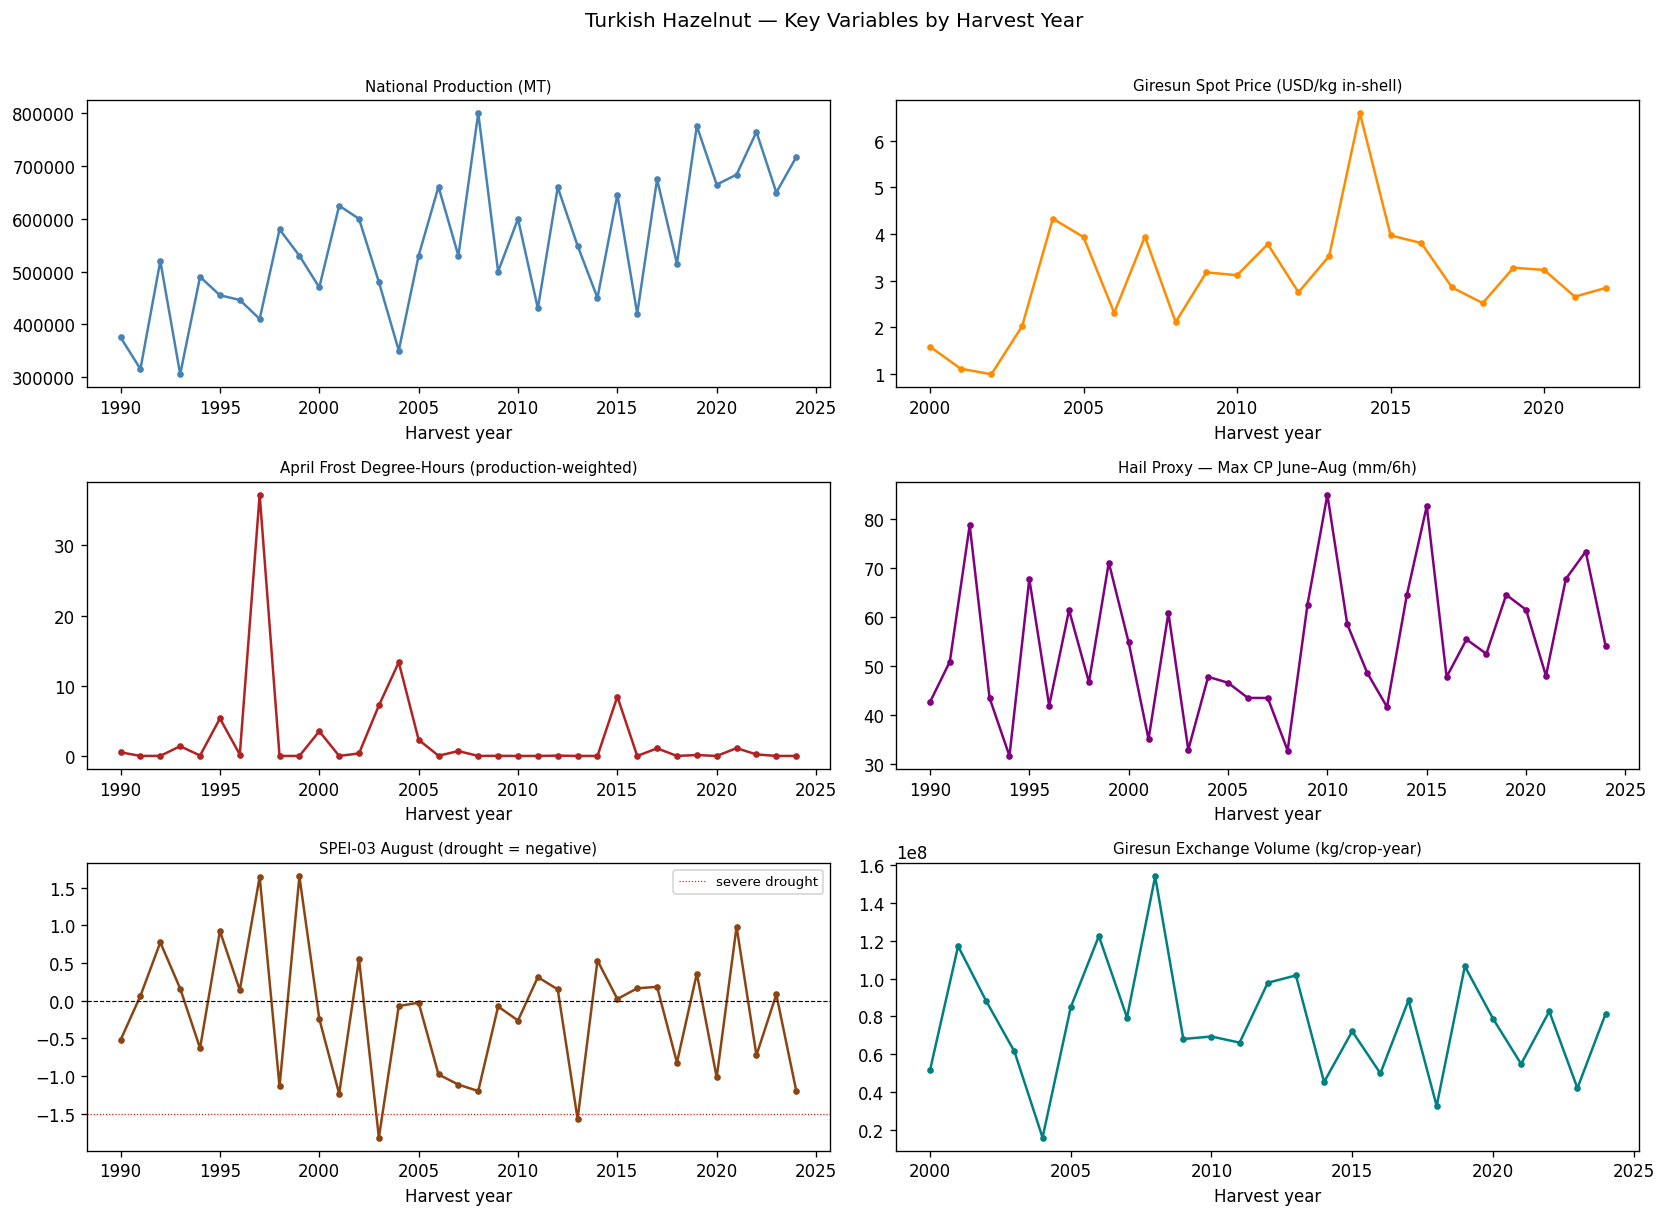

In [6]:
# ── 2a. Time series ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

plots = [
    ('production_mt',  'National Production (MT)', 'steelblue'),
    ('price_usd_kg',   'Giresun Spot Price (USD/kg in-shell)', 'darkorange'),
    ('april_dh',       'April Frost Degree-Hours (production-weighted)', 'firebrick'),
    ('hail_cp_max',    'Hail Proxy — Max CP June–Aug (mm/6h)', 'purple'),
    ('spei_aug',       'SPEI-03 August (drought = negative)', 'saddlebrown'),
    ('giresun_vol_kg', 'Giresun Exchange Volume (kg/crop-year)', 'teal'),
]

for ax, (col, label, color) in zip(axes, plots):
    s = master[col].dropna()
    ax.plot(s.index, s.values, color=color, lw=1.5, marker='o', ms=3)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Harvest year')
    if col == 'spei_aug':
        ax.axhline(0, color='black', lw=0.7, ls='--')
        ax.axhline(-1.5, color='red', lw=0.7, ls=':', label='severe drought')
        ax.legend(fontsize=8)

plt.suptitle('Turkish Hazelnut — Key Variables by Harvest Year', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

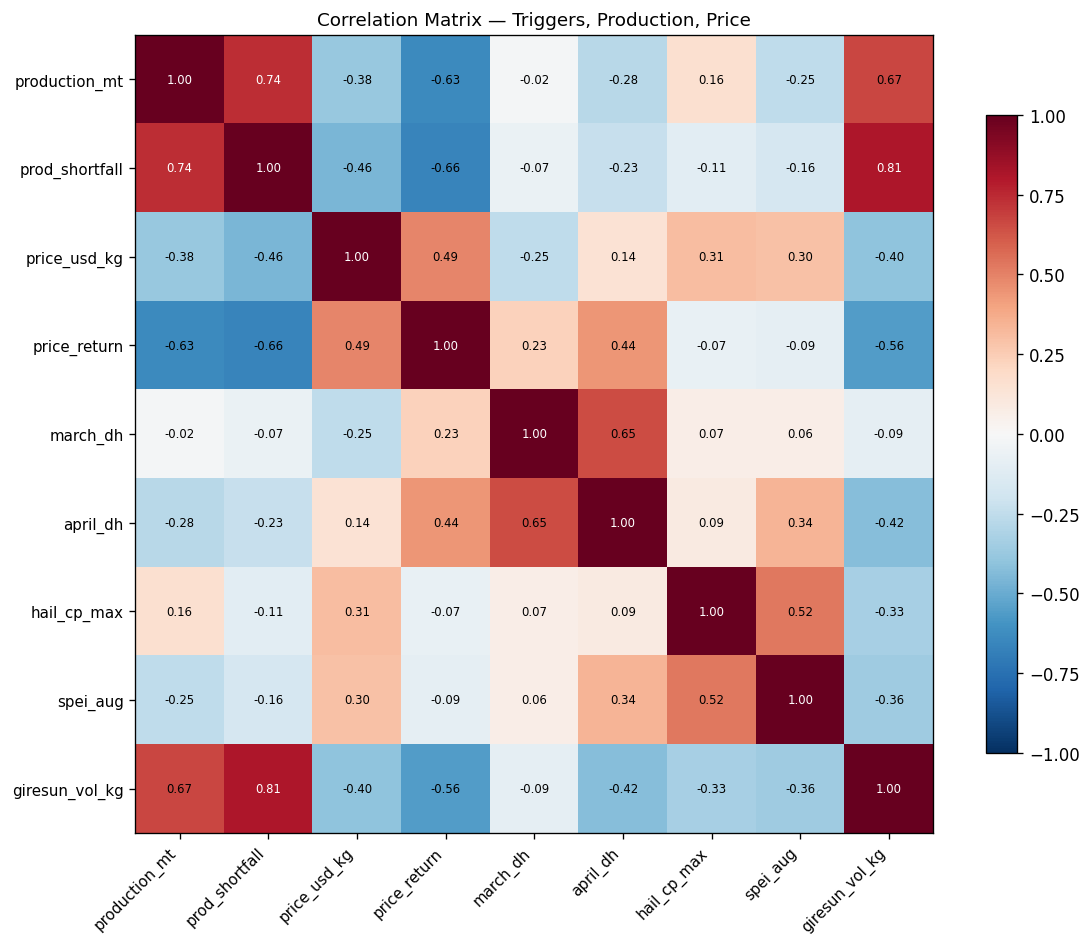

Key correlations with production_mt:
march_dh         -0.02
april_dh         -0.28
hail_cp_max       0.16
spei_aug         -0.25
giresun_vol_kg    0.67

Key correlations with price_return:
prod_shortfall   -0.66
march_dh          0.23
april_dh          0.44
hail_cp_max      -0.07
spei_aug         -0.09


In [7]:
# ── 2b. Correlation matrix ─────────────────────────────────────────────────────

corr_cols = ['production_mt', 'prod_shortfall', 'price_usd_kg', 'price_return',
             'march_dh', 'april_dh', 'hail_cp_max', 'spei_aug', 'giresun_vol_kg']
corr = master[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white')
ax.set_title('Correlation Matrix — Triggers, Production, Price', fontsize=11)
plt.tight_layout()
plt.show()

print('Key correlations with production_mt:')
print(corr['production_mt'][['march_dh','april_dh','hail_cp_max','spei_aug','giresun_vol_kg']].to_string())
print('\nKey correlations with price_return:')
print(corr['price_return'][['prod_shortfall','march_dh','april_dh','hail_cp_max','spei_aug']].to_string())

## 3. Model A: Event Triggers → National Production

**Hypothesis**: Spring frost, summer hail, and summer drought reduce national hazelnut output.
Giresun exchange volume is included as a contemporaneous proxy signal (not a causal trigger).

**Target**: TÜİK/FAOSTAT national production (MT)

**Note on sign direction**:
- `april_dh` — more frost DH → lower production (expected: negative coefficient)
- `hail_cp_max` — more convective precip → lower production (expected: negative coefficient)  
- `spei_aug` — higher SPEI (wetter) → higher production (expected: positive coefficient)
- `giresun_vol_kg` — more Giresun clearing → higher national production (expected: positive coefficient)

In [8]:
# ── 3a. Full-period regression: weather triggers → production (1990–2024) ─────

feat_prod_full = ['march_dh', 'april_dh', 'hail_cp_max', 'spei_aug']
df_prod_full   = master[feat_prod_full + ['production_mt']].dropna()

X_pf = sm.add_constant(df_prod_full[feat_prod_full])
y_pf = df_prod_full['production_mt']

res_prod_full = sm.OLS(y_pf, X_pf).fit()
print(res_prod_full.summary())
print(f'\nSample: {df_prod_full.index.min()}–{df_prod_full.index.max()}, n={len(df_prod_full)}')

                            OLS Regression Results                            
Dep. Variable:          production_mt   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     2.173
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0961
Time:                        13:02:57   Log-Likelihood:                -456.92
No. Observations:                  35   AIC:                             923.8
Df Residuals:                      30   BIC:                             931.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3.634e+05   1.03e+05      3.536      

In [9]:
# ── 3b. With Giresun volume added (2000–2024 only) ────────────────────────────

feat_prod_g  = ['march_dh', 'april_dh', 'hail_cp_max', 'spei_aug', 'giresun_vol_kg']
df_prod_g    = master[feat_prod_g + ['production_mt']].dropna()

X_pg = sm.add_constant(df_prod_g[feat_prod_g])
y_pg = df_prod_g['production_mt']

res_prod_g = sm.OLS(y_pg, X_pg).fit()
print(res_prod_g.summary())
print(f'\nSample: {df_prod_g.index.min()}–{df_prod_g.index.max()}, n={len(df_prod_g)}')

                            OLS Regression Results                            
Dep. Variable:          production_mt   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     5.838
Date:                Thu, 07 May 2026   Prob (F-statistic):            0.00198
Time:                        13:02:57   Log-Likelihood:                -315.74
No. Observations:                  25   AIC:                             643.5
Df Residuals:                      19   BIC:                             650.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1.809e+05   1.13e+05      1.

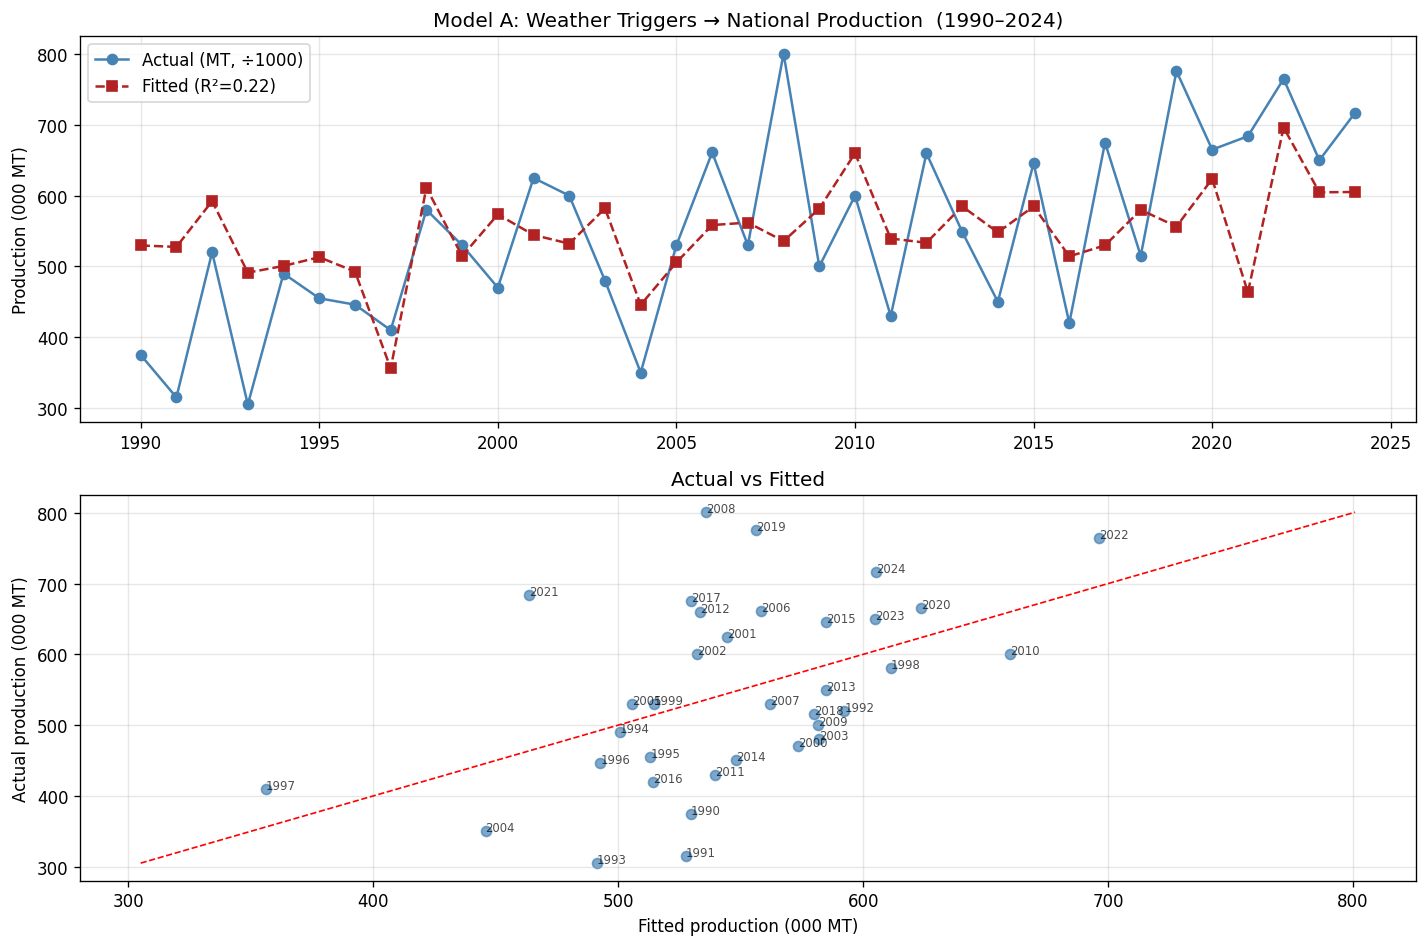

In [10]:
# ── 3c. Visualise: actual vs fitted production + residuals ────────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Actual vs fitted
fitted_full  = res_prod_full.fittedvalues
ax1.plot(df_prod_full.index, y_pf.values / 1e3, 'o-', label='Actual (MT, ÷1000)', color='steelblue')
ax1.plot(df_prod_full.index, fitted_full.values / 1e3, 's--', label=f'Fitted (R²={res_prod_full.rsquared:.2f})', color='firebrick')
ax1.set_ylabel('Production (000 MT)')
ax1.set_title('Model A: Weather Triggers → National Production  (1990–2024)')
ax1.legend()
ax1.grid(alpha=0.3)

# Scatter: actual vs fitted
ax2.scatter(fitted_full.values / 1e3, y_pf.values / 1e3, alpha=0.7, color='steelblue')
mn, mx = y_pf.min() / 1e3, y_pf.max() / 1e3
ax2.plot([mn, mx], [mn, mx], 'r--', lw=1)
for yr in df_prod_full.index:
    ax2.annotate(str(yr), (fitted_full.loc[yr] / 1e3, y_pf.loc[yr] / 1e3),
                 fontsize=7, alpha=0.7)
ax2.set_xlabel('Fitted production (000 MT)')
ax2.set_ylabel('Actual production (000 MT)')
ax2.set_title('Actual vs Fitted')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

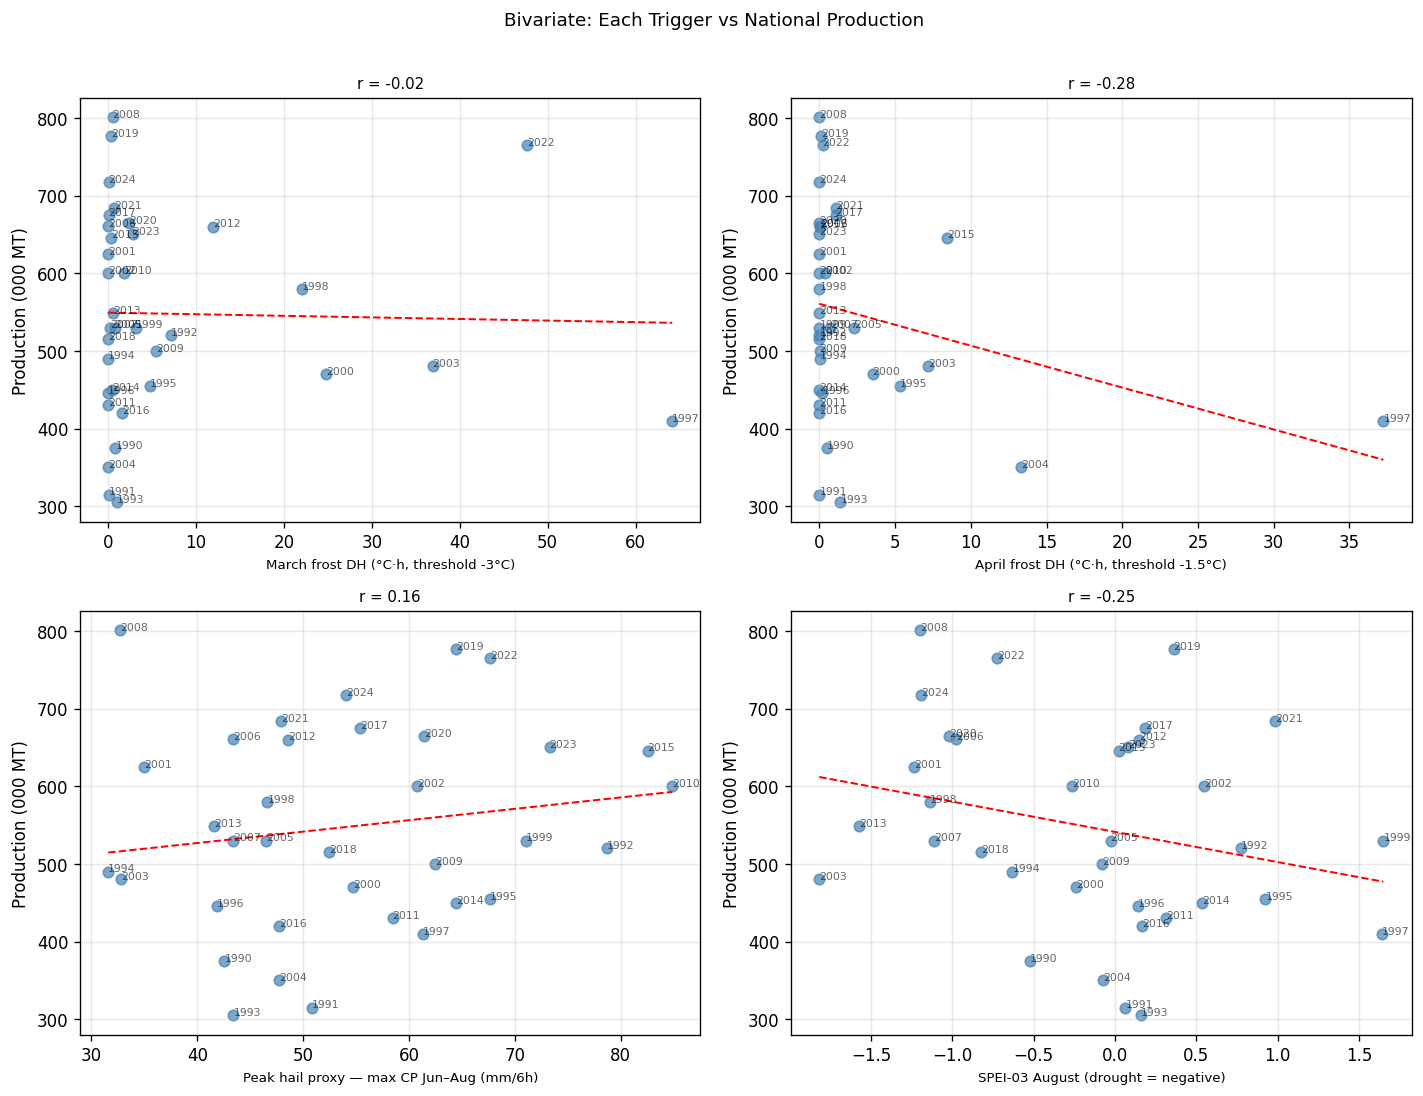

In [11]:
# ── 3d. Partial regression plots: each trigger vs production ──────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

trigger_labels = {
    'march_dh':   'March frost DH (°C·h, threshold -3°C)',
    'april_dh':   'April frost DH (°C·h, threshold -1.5°C)',
    'hail_cp_max':'Peak hail proxy — max CP Jun–Aug (mm/6h)',
    'spei_aug':   'SPEI-03 August (drought = negative)',
}

for ax, col in zip(axes.flatten(), feat_prod_full):
    x = df_prod_full[col]
    y = df_prod_full['production_mt'] / 1e3
    ax.scatter(x, y, alpha=0.7, color='steelblue', s=40)
    for yr in df_prod_full.index:
        ax.annotate(str(yr), (x.loc[yr], y.loc[yr]), fontsize=6.5, alpha=0.6)
    m, b = np.polyfit(x.values, y.values, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, m*xs + b, 'r--', lw=1.2)
    r = np.corrcoef(x.values, y.values)[0, 1]
    ax.set_xlabel(trigger_labels[col], fontsize=8)
    ax.set_ylabel('Production (000 MT)')
    ax.set_title(f'r = {r:.2f}', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Bivariate: Each Trigger vs National Production', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

## 4. Production → Price: The Supply/Demand Bridge

Turkey produces ~590% of domestic consumption — it is overwhelmingly export-oriented.
When production falls below trend, the global market tightens and prices rise.

**Variable construction**:
- `prod_shortfall` = (production - 5yr rolling avg) / 5yr rolling avg  
  Positive = above-average crop; Negative = below-average crop (price should rise)
- `export_pull` = exports / production  
  High ratio = strong demand relative to supply
- `stock_draw` = stock_change / production  
  Negative = stocks being drawn down (supply tight)

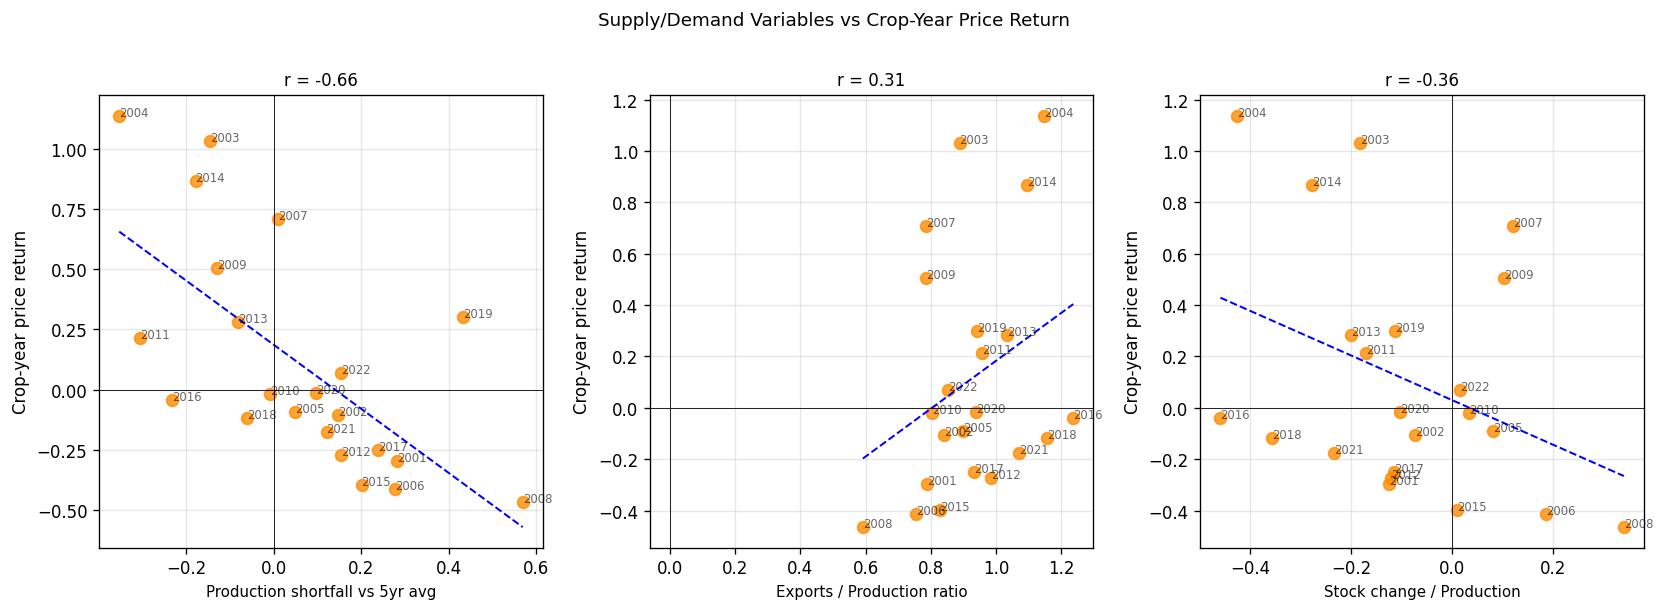

In [12]:
# ── 4a. Scatter: production shortfall vs price return ─────────────────────────

df_bridge = master[['prod_shortfall', 'price_return', 'exports_mt',
                     'stock_change_mt', 'production_mt']].dropna()
df_bridge['export_pull']  = df_bridge['exports_mt'] / df_bridge['production_mt']
df_bridge['stock_draw']   = df_bridge['stock_change_mt'] / df_bridge['production_mt']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

scatter_vars = [
    ('prod_shortfall', 'Production shortfall vs 5yr avg'),
    ('export_pull',    'Exports / Production ratio'),
    ('stock_draw',     'Stock change / Production'),
]
for ax, (col, label) in zip(axes, scatter_vars):
    x = df_bridge[col]
    y = df_bridge['price_return']
    ax.scatter(x, y, alpha=0.8, color='darkorange', s=50)
    for yr in df_bridge.index:
        ax.annotate(str(yr), (x.loc[yr], y.loc[yr]), fontsize=7, alpha=0.6)
    m, b = np.polyfit(x.values, y.values, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, m*xs + b, 'b--', lw=1.2)
    r = np.corrcoef(x.values, y.values)[0, 1]
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Crop-year price return')
    ax.set_title(f'r = {r:.2f}', fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Supply/Demand Variables vs Crop-Year Price Return', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ── 4b. OLS: production shortfall → price return ──────────────────────────────

feat_bridge  = ['prod_shortfall', 'export_pull', 'stock_draw']
df_bridge_ols = df_bridge[feat_bridge + ['price_return']].dropna()

X_b = sm.add_constant(df_bridge_ols[feat_bridge])
y_b = df_bridge_ols['price_return']

res_bridge = sm.OLS(y_b, X_b).fit()
print(res_bridge.summary())
print(f'\nSample: {df_bridge_ols.index.min()}–{df_bridge_ols.index.max()}, n={len(df_bridge_ols)}')
print('\nInterpretation: A 10% production shortfall implies a',
      f'{-res_bridge.params["prod_shortfall"] * 0.10 * 100:.1f}% change in crop-year price.')

                            OLS Regression Results                            
Dep. Variable:           price_return   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     5.302
Date:                Thu, 07 May 2026   Prob (F-statistic):            0.00852
Time:                        13:02:58   Log-Likelihood:                -7.1547
No. Observations:                  22   AIC:                             22.31
Df Residuals:                      18   BIC:                             26.67
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.5087      1.275      1.

## 5. Full Causal Chain: Triggers → Price (Direct)

Run weather triggers directly against price return for comparison.
This collapses the two-stage chain into one regression — useful for checking
that the signal survives end-to-end without explicitly routing through production.

Also include Giresun volume as a contemporaneous supply signal.

In [14]:
# ── 5a. Triggers → Price (direct, no production) ─────────────────────────────

feat_direct = ['march_dh', 'april_dh', 'hail_cp_max', 'spei_aug']
df_direct   = master[feat_direct + ['price_return']].dropna()

X_d = sm.add_constant(df_direct[feat_direct])
y_d = df_direct['price_return']

res_direct = sm.OLS(y_d, X_d).fit()
print(res_direct.summary())
print(f'\nSample: {df_direct.index.min()}–{df_direct.index.max()}, n={len(df_direct)}')

                            OLS Regression Results                            
Dep. Variable:           price_return   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     1.289
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.313
Time:                        13:02:58   Log-Likelihood:                -11.205
No. Observations:                  22   AIC:                             32.41
Df Residuals:                      17   BIC:                             37.87
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1249      0.475      0.263      

In [15]:
# ── 5b. Triggers + Giresun volume → Price (2000–2024) ─────────────────────────

feat_full = ['march_dh', 'april_dh', 'hail_cp_max', 'spei_aug', 'giresun_vol_kg']
df_full   = master[feat_full + ['price_return']].dropna()

X_f = sm.add_constant(df_full[feat_full])
y_f = df_full['price_return']

res_full = sm.OLS(y_f, X_f).fit()
print(res_full.summary())
print(f'\nSample: {df_full.index.min()}–{df_full.index.max()}, n={len(df_full)}')

                            OLS Regression Results                            
Dep. Variable:           price_return   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     2.657
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0621
Time:                        13:02:58   Log-Likelihood:                -7.4697
No. Observations:                  22   AIC:                             26.94
Df Residuals:                      16   BIC:                             33.49
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.9944      0.536      1.

## 6. Summary: Causal Chain Evidence

Three regression stages, each confirming one link in the causal chain.

In [16]:
# ── 6. Summary table and path diagram ─────────────────────────────────────────

print('=' * 70)
print('CAUSAL CHAIN SUMMARY')
print('=' * 70)

print('\n── Stage 1: Weather Triggers → National Production ──────────────────')
print(f'  R² = {res_prod_full.rsquared:.3f}   Adj-R² = {res_prod_full.rsquared_adj:.3f}')
for var in feat_prod_full:
    coef = res_prod_full.params[var]
    pval = res_prod_full.pvalues[var]
    sig  = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f'  {var:20s}  coef={coef:>12,.1f}  p={pval:.3f} {sig}')

print('\n── Stage 2: Production Shortfall → Price Return ─────────────────────')
print(f'  R² = {res_bridge.rsquared:.3f}   Adj-R² = {res_bridge.rsquared_adj:.3f}')
for var in feat_bridge:
    coef = res_bridge.params[var]
    pval = res_bridge.pvalues[var]
    sig  = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f'  {var:20s}  coef={coef:>8.3f}  p={pval:.3f} {sig}')

print('\n── Stage 3: Triggers → Price (direct path check) ────────────────────')
print(f'  R² = {res_direct.rsquared:.3f}   Adj-R² = {res_direct.rsquared_adj:.3f}')
for var in feat_direct:
    coef = res_direct.params[var]
    pval = res_direct.pvalues[var]
    sig  = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f'  {var:20s}  coef={coef:>8.4f}  p={pval:.3f} {sig}')

print('\n' + '=' * 70)
print('Significance: *** p<0.01  ** p<0.05  * p<0.10')

CAUSAL CHAIN SUMMARY

── Stage 1: Weather Triggers → National Production ──────────────────
  R² = 0.225   Adj-R² = 0.121
  march_dh              coef=     1,518.8  p=0.439 
  april_dh              coef=    -5,896.4  p=0.205 
  hail_cp_max           coef=     3,295.8  p=0.075 *
  spei_aug              coef=   -53,229.2  p=0.108 

── Stage 2: Production Shortfall → Price Return ─────────────────────
  R² = 0.469   Adj-R² = 0.381
  prod_shortfall        coef=  -1.492  p=0.004 ***
  export_pull           coef=  -1.511  p=0.320 
  stock_draw            coef=  -0.874  p=0.461 

── Stage 3: Triggers → Price (direct path check) ────────────────────
  R² = 0.233   Adj-R² = 0.052
  march_dh              coef=  0.0071  p=0.421 
  april_dh              coef=  0.0567  p=0.067 *
  hail_cp_max           coef= -0.0025  p=0.761 
  spei_aug              coef=  0.0107  p=0.947 

Significance: *** p<0.01  ** p<0.05  * p<0.10


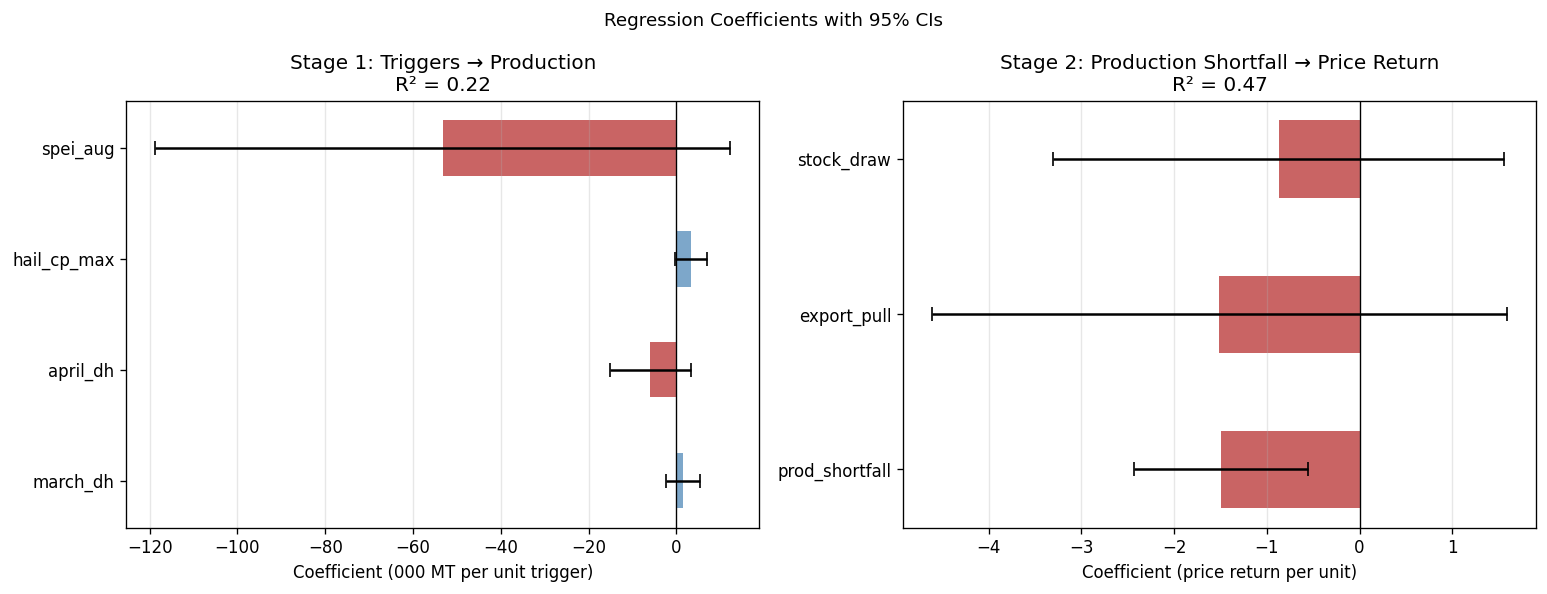

In [17]:
# ── 6b. Coefficient chart — production model ──────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Stage 1 coefficients (production model)
params1  = res_prod_full.params[feat_prod_full]
ci1      = res_prod_full.conf_int().loc[feat_prod_full]
colors1  = ['firebrick' if c < 0 else 'steelblue' for c in params1]
y1 = range(len(feat_prod_full))
ax1.barh(y1, params1.values / 1e3, color=colors1, alpha=0.7, height=0.5)
ax1.errorbar(params1.values / 1e3, y1,
             xerr=[(params1 - ci1[0]).values / 1e3, (ci1[1] - params1).values / 1e3],
             fmt='none', color='black', capsize=4, lw=1.5)
ax1.axvline(0, color='black', lw=0.8)
ax1.set_yticks(y1)
ax1.set_yticklabels(feat_prod_full)
ax1.set_xlabel('Coefficient (000 MT per unit trigger)')
ax1.set_title(f'Stage 1: Triggers → Production\nR² = {res_prod_full.rsquared:.2f}')
ax1.grid(axis='x', alpha=0.3)

# Stage 2 coefficients (price model)
params2  = res_bridge.params[feat_bridge]
ci2      = res_bridge.conf_int().loc[feat_bridge]
colors2  = ['firebrick' if c < 0 else 'steelblue' for c in params2]
y2 = range(len(feat_bridge))
ax2.barh(y2, params2.values, color=colors2, alpha=0.7, height=0.5)
ax2.errorbar(params2.values, y2,
             xerr=[(params2 - ci2[0]).values, (ci2[1] - params2).values],
             fmt='none', color='black', capsize=4, lw=1.5)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y2)
ax2.set_yticklabels(feat_bridge)
ax2.set_xlabel('Coefficient (price return per unit)')
ax2.set_title(f'Stage 2: Production Shortfall → Price Return\nR² = {res_bridge.rsquared:.2f}')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Regression Coefficients with 95% CIs', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Implied Payout Sensitivity

Using the regression coefficients, estimate the implied price impact of each trigger event
at various severity levels. This feeds directly into payout structure calibration.

**Chain**: trigger intensity → production shortfall (via Stage 1 β) → price return (via Stage 2 β on shortfall)

In [18]:
# ── 7. Implied price impact table ─────────────────────────────────────────────

# Stage 1 betas: trigger → production (MT)
b_march   = res_prod_full.params['march_dh']
b_april   = res_prod_full.params['april_dh']
b_hail    = res_prod_full.params['hail_cp_max']
b_spei    = res_prod_full.params['spei_aug']

# Stage 2 beta: prod_shortfall → price_return
b_shortfall = res_bridge.params['prod_shortfall']

# Baseline production (5yr avg of recent data)
baseline_prod = master['production_mt'].dropna().tail(10).mean()

print(f'Baseline production (10yr avg): {baseline_prod:,.0f} MT')
print(f'Stage 2 β (shortfall→price): {b_shortfall:.3f}')
print()

print(f'{"Trigger":<30} {"Scenario":<20} {"Prod Δ (MT)":>12} {"Shortfall":>10} {"ΔPrice":>10}')
print('-' * 84)

scenarios = [
    # (name, variable, beta, test_values, unit_desc)
    ('April frost', 'april_dh', b_april,
     [(50, 'mild (50 DH)'), (200, 'moderate (200 DH)'), (500, 'severe (500 DH)')]),
    ('March frost', 'march_dh', b_march,
     [(50, 'mild (50 DH)'), (200, 'moderate (200 DH)'), (500, 'severe (500 DH)')]),
    ('Hail proxy',  'hail_cp_max', b_hail,
     [(8, 'threshold (8mm)'), (15, 'moderate (15mm)'), (25, 'severe (25mm)')]),
    ('SPEI drought','spei_aug', b_spei,
     [(-1.5, 'severe (-1.5)'), (-2.0, 'extreme (-2.0)'), (-2.5, 'catastrophic (-2.5)')]),
]

for trigger_name, var, beta, test_vals in scenarios:
    for val, desc in test_vals:
        prod_delta    = beta * val
        shortfall     = prod_delta / baseline_prod
        price_impact  = b_shortfall * shortfall
        print(f'{trigger_name:<30} {desc:<20} {prod_delta:>12,.0f} {shortfall:>10.1%} {price_impact:>10.1%}')
    print()

Baseline production (10yr avg): 651,305 MT
Stage 2 β (shortfall→price): -1.492

Trigger                        Scenario              Prod Δ (MT)  Shortfall     ΔPrice
------------------------------------------------------------------------------------
April frost                    mild (50 DH)             -294,819     -45.3%      67.6%
April frost                    moderate (200 DH)      -1,179,277    -181.1%     270.2%
April frost                    severe (500 DH)        -2,948,191    -452.7%     675.5%

March frost                    mild (50 DH)               75,941      11.7%     -17.4%
March frost                    moderate (200 DH)         303,764      46.6%     -69.6%
March frost                    severe (500 DH)           759,410     116.6%    -174.0%

Hail proxy                     threshold (8mm)            26,367       4.0%      -6.0%
Hail proxy                     moderate (15mm)            49,437       7.6%     -11.3%
Hail proxy                     severe (25mm)      